# Counterfeit Medicine Detection Using Machine Learning Classifiers

**Research Paper:** *"Analyzing the Counterfeit Medicines Based on Classification Using Machine Learning Techniques"*  
**Authors:** Binitha S. Thomson and W. Rose Varuna  
**Published:** Proceedings of Fifth International Conference on Computer and Communication Technologies, Springer (2024)

---

### Objective
Classify medicines as **authentic** or **counterfeit** from images using ML algorithms:  
RF, NB, KNN, SVM (from paper) + **XGBoost** (our addition).

### Pipeline
1. Dataset exploration & class distribution analysis
2. YOLOv8 object detection - crop individual medicines
3. Merge all crops - stratified 80/20 train/test split
4. Feature extraction (Color, Texture, Shape, Edges)
5. Train & evaluate 5 ML classifiers
6. Compare results & verify on independent test images

---
## 1. Import Libraries

We begin by importing all the necessary Python libraries for the pipeline. These include:

- **OpenCV (cv2):** For image loading, resizing, and color space conversions
- **Ultralytics YOLO:** For training the object detection model and extracting medicine crops
- **scikit-image:** For texture and gradient feature extraction (LBP, GLCM, HOG)
- **scikit-learn:** For ML classifiers (RF, NB, KNN, SVM), feature scaling, and evaluation metrics
- **XGBoost:** For gradient boosting classification (our additional contribution)
- **matplotlib / seaborn:** For result visualization and plotting

In [1]:
import os
import warnings
import time
import numpy as np
import cv2
from collections import Counter

from ultralytics import YOLO
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd

warnings.filterwarnings('ignore')
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Dataset Exploration

Our dataset follows the **YOLO object detection format**, where each image has an associated label file containing bounding box annotations.

### What are Annotations?

In object detection, **annotations** are text files that describe *what* objects are in an image and *where* they are located. Each image has a corresponding `.txt` label file. Every line in the label file represents one object using this format:

```
<class_id> <x_center> <y_center> <width> <height>
```

- **class_id:** The class label (0 = Authentic, 1 = Counterfeit)
- **x_center, y_center:** The center of the bounding box, normalized between 0 and 1 relative to image dimensions
- **width, height:** The size of the bounding box, also normalized between 0 and 1

For example: `0 0.512 0.430 0.280 0.350` means an Authentic medicine is centered at (51.2%, 43.0%) of the image, spanning 28% width and 35% height.

A single image can have **multiple annotations** if it contains more than one medicine object. This is why we count individual annotations (not just images) when analyzing class distribution.

### 2.1 Count Images & Labels Per Split

We count images and label files across the three dataset splits (train, valid, test) to understand the dataset size.

In [2]:
split_info = {}
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(split, 'images')
    lbl_dir = os.path.join(split, 'labels')
    n_img = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg','.png'))])
    n_lbl = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')])
    split_info[split] = {'images': n_img, 'labels': n_lbl}
    print(f'{split.upper():>6}: {n_img} images, {n_lbl} labels')

print(f'\nTotal: {sum(s["images"] for s in split_info.values())} images')

 TRAIN: 4072 images, 4072 labels
 VALID: 122 images, 122 labels
  TEST: 65 images, 65 labels

Total: 4259 images


### 2.2 Class Distribution Analysis

We parse every label file across all splits and count the number of bounding box annotations per class. This reveals the true class imbalance in our dataset -- understanding this is critical because significant imbalance can bias models toward the majority class.

In [3]:
# Count annotations per class across ALL splits
class_dist = {}

for split in ['train', 'valid', 'test']:
    lbl_dir = os.path.join(split, 'labels')
    counter = Counter()
    
    for lbl_file in os.listdir(lbl_dir):
        if not lbl_file.endswith('.txt'):
            continue
        with open(os.path.join(lbl_dir, lbl_file), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:  # class_id x_center y_center width height
                    counter[parts[0]] += 1
    
    class_dist[split] = counter
    auth = counter.get('0', 0)
    fake = counter.get('1', 0)
    print(f'{split.upper():>6} -- Authentic: {auth:>5} annotations | Counterfeit: {fake:>4} annotations | Total: {auth+fake}')

# Grand total
total_auth = sum(d.get('0', 0) for d in class_dist.values())
total_fake = sum(d.get('1', 0) for d in class_dist.values())
print(f'{"TOTAL":>6} -- Authentic: {total_auth:>5} annotations | Counterfeit: {total_fake:>4} annotations | Total: {total_auth+total_fake}')
print(f'\nClass ratio: {total_auth/total_fake:.1f}:1 (authentic : counterfeit)')

 TRAIN -- Authentic:  6696 annotations | Counterfeit:  567 annotations | Total: 7263
 VALID -- Authentic:   184 annotations | Counterfeit:   56 annotations | Total: 240
  TEST -- Authentic:   109 annotations | Counterfeit:   25 annotations | Total: 134
 TOTAL -- Authentic:  6989 annotations | Counterfeit:  648 annotations | Total: 7637

Class ratio: 10.8:1 (authentic : counterfeit)


### 2.3 Sample Images with Bounding Box Annotations

We visualize training images with their YOLO bounding boxes overlaid to verify annotations are correctly aligned with actual medicine objects.

- **Green boxes** = Authentic medicine (class 0)
- **Red boxes** = Counterfeit medicine (class 1)

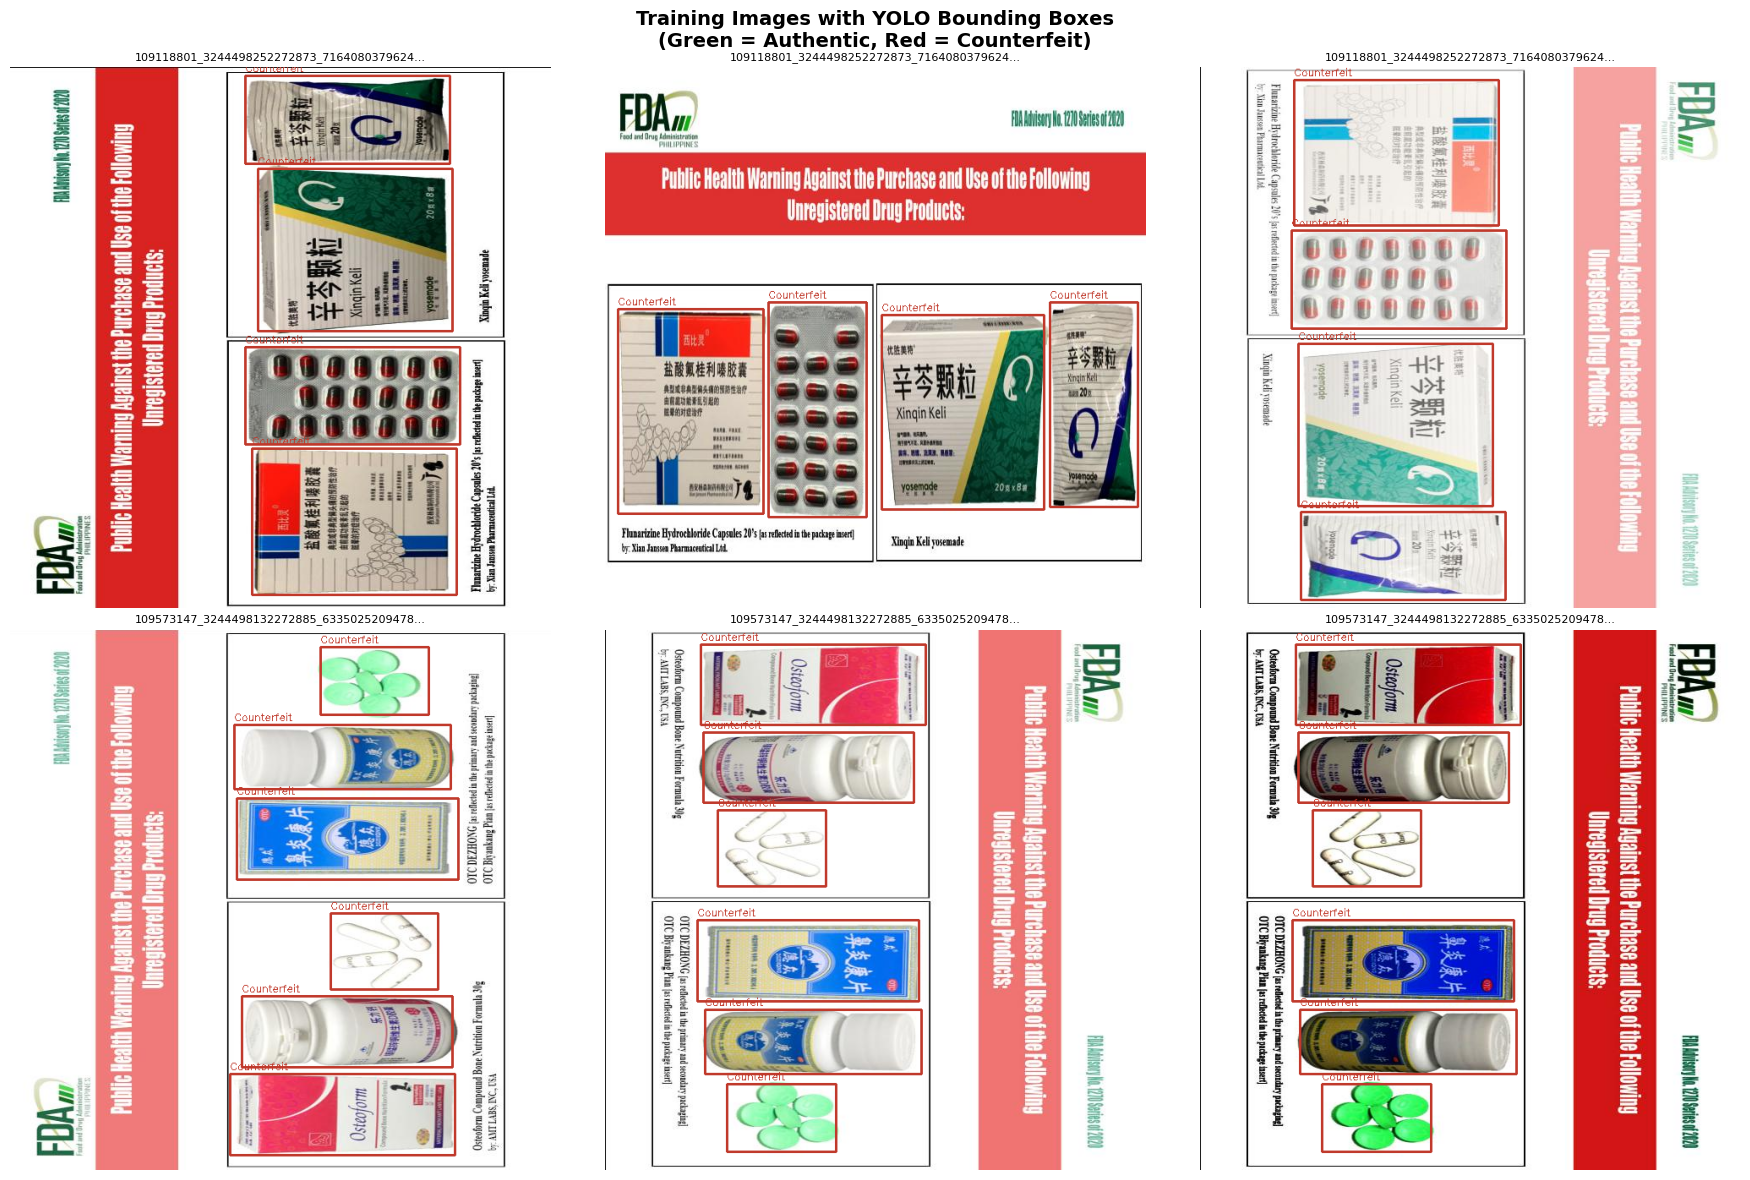

In [4]:
def draw_yolo_boxes(img_path, lbl_path):
    """Draw YOLO bounding boxes on an image. Green=authentic, Red=counterfeit."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = [float(v) for v in parts[1:5]]
                # Convert YOLO format to pixel coordinates
                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)
                color = (39, 174, 96) if cls_id == 0 else (192, 57, 43)  # Green / Red
                label = 'Authentic' if cls_id == 0 else 'Counterfeit'
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return img

# Show 6 sample images with bounding boxes
img_files = sorted(os.listdir('train/images'))[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, fname in enumerate(img_files):
    ax = axes[i // 3, i % 3]
    img_path = os.path.join('train/images', fname)
    lbl_path = os.path.join('train/labels', fname.replace('.jpg', '.txt').replace('.png', '.txt'))
    img_with_boxes = draw_yolo_boxes(img_path, lbl_path)
    ax.imshow(img_with_boxes)
    ax.set_title(fname[:40] + '...', fontsize=8)
    ax.axis('off')

plt.suptitle('Training Images with YOLO Bounding Boxes\n(Green = Authentic, Red = Counterfeit)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. YOLOv8 Object Detection & Crop Extraction

We use **YOLOv8** to detect individual medicine objects in images and save each detected object as a separate cropped image. This converts our detection dataset into a **classification dataset** suitable for traditional ML algorithms.

### 3.1 Train YOLOv8 Model

In [ ]:
# Load pretrained YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Train on our counterfeit medicine dataset
model.train(
    data='data.yaml',
    epochs=20,
    imgsz=416,
    batch=4,
    workers=0
)

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.15  Python-3.14.3 torch-2.10.0+cpu CPU (AMD Ryzen 7 7840HS w/ Radeon 780M Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train27, nbs=64, nm

### 3.2 Validate the Trained Model

In [ ]:
model.val(data='data.yaml')

### 3.3 Extract Crops from All Images

Run prediction with `save_crop=True` on **all images** (train + valid + test).  
This saves detected objects as individual cropped images organized by class name.

In [ ]:
# Load the best trained weights
best_weights = sorted(
    [d for d in os.listdir('runs/detect') if d.startswith('train')],
    key=lambda x: int(x.replace('train', '') or '0')
)[-1]
weight_path = f'runs/detect/{best_weights}/weights/best.pt'
print(f'Using weights: {weight_path}')

model = YOLO(weight_path)

# Run prediction on ALL splits to get crops
for split in ['train', 'valid', 'test']:
    print(f'\nProcessing {split}...')
    model.predict(
        source=f'{split}/images',
        save_crop=True,
        conf=0.25,
        imgsz=416
    )

print('\nCrop extraction complete!')

### 3.4 Verify Extracted Crops

In [ ]:
crops_dir = 'runs/detect/predict/crops'

crop_counts = {}
for cls in ['authentic', 'counterfeit']:
    cls_dir = os.path.join(crops_dir, cls)
    count = len([f for f in os.listdir(cls_dir) if f.endswith(('.jpg','.png'))])
    crop_counts[cls] = count
    print(f'{cls}: {count} crops')

total_crops = sum(crop_counts.values())
print(f'\nTotal crops for ML classification: {total_crops}')

### 3.5 Visualize Sample Crops

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for row, cls in enumerate(['authentic', 'counterfeit']):
    cls_dir = os.path.join(crops_dir, cls)
    files = sorted(os.listdir(cls_dir))[:6]
    color = '#27ae60' if cls == 'authentic' else '#c0392b'
    for col, f in enumerate(files):
        img = cv2.imread(os.path.join(cls_dir, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls.upper(), fontsize=9, color=color, fontweight='bold')
        # Draw outline border
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

plt.suptitle('Extracted Crop Samples\n(Green border = Authentic, Red border = Counterfeit)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Data Preparation -- Merge & Split

The original dataset has an **imbalanced split** (4072 train vs 65 test images).  
We **merge all extracted crops** into a single pool and then apply a proper **stratified 80/20 train/test split** to ensure fair evaluation.

### 4.1 Load All Crops

In [ ]:
image_paths = []
labels = []

for class_name in ['authentic', 'counterfeit']:
    class_dir = os.path.join(crops_dir, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    label = 0 if class_name == 'authentic' else 1
    for f in files:
        image_paths.append(os.path.join(class_dir, f))
        labels.append(label)
    print(f'Loaded {class_name}: {len(files)} images (label={label})')

labels = np.array(labels)
print(f'\nTotal merged pool: {len(image_paths)} images')
print(f'  Authentic:   {np.sum(labels==0)}')
print(f'  Counterfeit: {np.sum(labels==1)}')

### 4.2 Stratified 80/20 Train/Test Split

Stratified split ensures both train and test sets maintain the **same class ratio**.

In [ ]:
paths_train, paths_test, y_train, y_test = train_test_split(
    image_paths, labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print('AFTER STRATIFIED SPLIT:')
print(f'  Train: {len(paths_train)} images')
print(f'    Authentic:   {np.sum(y_train==0)} ({np.sum(y_train==0)/len(y_train)*100:.1f}%)')
print(f'    Counterfeit: {np.sum(y_train==1)} ({np.sum(y_train==1)/len(y_train)*100:.1f}%)')
print(f'\n  Test:  {len(paths_test)} images')
print(f'    Authentic:   {np.sum(y_test==0)} ({np.sum(y_test==0)/len(y_test)*100:.1f}%)')
print(f'    Counterfeit: {np.sum(y_test==1)} ({np.sum(y_test==1)/len(y_test)*100:.1f}%)')
print(f'\nClass ratio preserved: ~{np.sum(y_train==0)/np.sum(y_train==1):.1f}:1 in both sets')

---
## 5. Feature Extraction

Feature extraction is the core of this pipeline. Instead of using raw pixel values (which are high-dimensional and noisy), we compute **handcrafted features** that mathematically capture specific visual properties of each medicine image. The reference paper identifies several discriminative properties that differ between authentic and counterfeit medicines:

- **Color** -- Manufacturing differences cause subtle variations in dye concentration, coating color, and packaging hue
- **Texture** -- Surface finish quality differs: genuine pills have smooth, uniform coatings while counterfeits often appear rougher or grainy
- **Shape** -- Counterfeit tablets may have slightly different dimensions, roundness, or embossing depth
- **Edges/Gradients** -- Embossed text, score lines, and logos on genuine medicines are sharp and well-defined, while counterfeits often have blurry or shallow reproductions

We extract 5 complementary feature types and concatenate them into a single feature vector per image. All images are resized to **128x128** pixels for consistency.

In [ ]:
IMG_SIZE = 128

### 5.1 Color Histogram (HSV)

**What it captures:** The overall color distribution of the medicine image. We use the HSV color space (Hue, Saturation, Value) instead of RGB because HSV separates color information from brightness, making features more robust to lighting changes.

**Method:** Compute a 3D histogram with 8 bins per channel (H, S, V).  
**Output:** 8 x 8 x 8 = **512 features**

In [ ]:
def extract_color_histogram(img_bgr):
    """Extract HSV color histogram (8x8x8 bins, normalized)."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8],
                        [0, 180, 0, 256, 0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist  # 512 features

# Demo
demo_img = cv2.imread(image_paths[0])
demo_img = cv2.resize(demo_img, (IMG_SIZE, IMG_SIZE))
color_feat = extract_color_histogram(demo_img)
print(f'Color Histogram: {color_feat.shape[0]} features')
print(f'Sample values: {color_feat[:5]}')

### 5.2 Local Binary Pattern (LBP) -- Texture

**What it captures:** Surface micro-texture patterns. For each pixel, LBP compares it with surrounding neighbors -- if a neighbor is brighter, the bit is set to 1, else 0. This creates a binary code per pixel. The histogram of these codes describes the texture.

**Why it matters:** Coating smoothness, granularity, and print quality differ between genuine and counterfeit medicines. LBP detects these local texture variations.

**Method:** Compute LBP with radius=3 and 24 neighbor points using the 'uniform' method.  
**Output:** **26 features** (histogram of uniform LBP patterns)

In [ ]:
def extract_lbp_features(img_gray):
    """Extract Local Binary Pattern histogram for texture analysis."""
    radius = 3
    n_points = 8 * radius  # 24 points
    lbp = local_binary_pattern(img_gray, n_points, radius, method='uniform')
    n_bins = n_points + 2  # 26 bins for uniform LBP
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist  # 26 features

# Demo
demo_gray = cv2.cvtColor(demo_img, cv2.COLOR_BGR2GRAY)
lbp_feat = extract_lbp_features(demo_gray)
print(f'LBP Texture: {lbp_feat.shape[0]} features')
print(f'Sample values: {lbp_feat[:5]}')

### 5.3 GLCM -- Texture Properties

**What it captures:** Statistical texture properties that measure how pixel intensity pairs are spatially distributed. Unlike LBP (which captures local patterns), GLCM captures global statistical relationships.

**Properties extracted:**
- **Contrast** -- intensity difference between neighboring pixels
- **Dissimilarity** -- mean absolute difference between neighbors
- **Homogeneity** -- how uniform the texture is
- **Energy** -- how repetitive/orderly the texture patterns are
- **Correlation** -- linear dependency between neighboring pixel intensities

**Method:** Compute Gray-Level Co-occurrence Matrix at multiple distances and angles, then extract 5 properties.  
**Output:** **5 features** (averaged across distances and angles)

In [ ]:
def extract_glcm_features(img_gray):
    """Extract GLCM texture features: contrast, dissimilarity, homogeneity, energy, correlation."""
    img_q = (img_gray // 4).astype(np.uint8)  # Quantize to 64 gray levels
    glcm = graycomatrix(img_q, distances=[1, 3], angles=[0, np.pi/4, np.pi/2],
                        levels=64, symmetric=True, normed=True)
    
    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    features = np.array([graycoprops(glcm, prop).mean() for prop in properties])
    return features  # 5 features

# Demo
glcm_feat = extract_glcm_features(demo_gray)
print(f'GLCM Texture: {glcm_feat.shape[0]} features')
props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
for p, v in zip(props, glcm_feat):
    print(f'  {p}: {v:.4f}')

### 5.4 Hu Moments -- Shape

**What it captures:** Seven mathematical descriptors that encode the geometric shape of the medicine object. These are special because they are **invariant** to translation (position), rotation (orientation), and scale (size) -- meaning a pill photographed at different angles or distances will produce similar Hu Moment values.

**Why it matters:** Counterfeit tablets often have slightly different dimensions, roundness, or embossing depth compared to genuine ones. Hu Moments detect these subtle geometric differences.

**Method:** Compute 7 Hu Moments from image moments, then apply log-transform for better numerical range.  
**Output:** **7 features**

In [ ]:
def extract_hu_moments(img_gray):
    """Extract Hu Moments -- 7 shape-invariant features."""
    moments = cv2.moments(img_gray)
    hu = cv2.HuMoments(moments).flatten()
    # Log transform: -sign(hu) * log10(|hu|) for better numerical range
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return hu  # 7 features

# Demo
hu_feat = extract_hu_moments(demo_gray)
print(f'Hu Moments: {hu_feat.shape[0]} features')
for i, v in enumerate(hu_feat):
    print(f'  Hu[{i+1}]: {v:.4f}')

### 5.5 HOG -- Histogram of Oriented Gradients

**What it captures:** The direction and strength of edges/gradients throughout the image. HOG divides the image into small cells, computes gradient histograms within each cell, and normalizes across blocks -- resulting in a rich descriptor of the object's structural outline.

**Why HOG is critical for counterfeit detection:**
- **Embossed text quality** -- genuine pills have sharp, well-defined embossed characters; counterfeits often show blurry or shallow embossing
- **Score line precision** -- the groove used to split tablets is precisely machined in authentic medicines
- **Logo/print clarity** -- text and logos on packaging or pill surfaces are crisper on genuine products
- **Edge sharpness** -- the boundary profile of authentic tablets is more consistent

HOG is the largest single feature group, contributing approximately 76% of the total feature vector.

**Method:** Compute HOG with 9 orientations, 16x16 pixel cells, and 2x2 cell blocks.  
**Output:** **1764 features**

In [ ]:
def extract_hog_features(img_gray):
    """Extract HOG (Histogram of Oriented Gradients) features."""
    features = hog(img_gray, orientations=9, pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2), feature_vector=True)
    return features  # 1764 features

# Demo
hog_feat = extract_hog_features(demo_gray)
print(f'HOG: {hog_feat.shape[0]} features')
print(f'Sample values: {hog_feat[:5]}')

### 5.6 Combined Feature Extraction

Combine all 5 feature groups into a single feature vector per image.

| # | Feature Group | Dimensions |
|---|--------------|------------|
| 1 | Color Histogram (HSV) | 512 |
| 2 | LBP Texture | 26 |
| 3 | GLCM Texture | 5 |
| 4 | Hu Moments (Shape) | 7 |
| 5 | HOG (Edges) | 1764 |
| | **Total** | **2314** |

In [ ]:
def extract_all_features(img_path):
    """Extract complete 2314-dimensional feature vector from a single image."""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    color = extract_color_histogram(img_bgr)     # 512
    lbp   = extract_lbp_features(img_gray)       # 26
    glcm  = extract_glcm_features(img_gray)      # 5
    hu    = extract_hu_moments(img_gray)          # 7
    hog_f = extract_hog_features(img_gray)        # 1764

    return np.concatenate([color, lbp, glcm, hu, hog_f])

# Verify
test_feat = extract_all_features(image_paths[0])
print(f'Total feature vector size: {len(test_feat)}')
print(f'  Color:  512')
print(f'  LBP:    26')
print(f'  GLCM:   5')
print(f'  Hu:     7')
print(f'  HOG:    {len(test_feat) - 512 - 26 - 5 - 7}')
print(f'  Total:  {len(test_feat)}')

### 5.7 Extract Features for Train & Test Sets

This step processes all images. Takes approximately **3-5 minutes**.

In [ ]:
def extract_batch(paths, label=''):
    """Extract features for a batch of image paths with progress."""
    feats, valid_idx = [], []
    total = len(paths)
    for i, p in enumerate(paths):
        if (i+1) % 500 == 0 or i == total-1:
            print(f'  {label} {i+1}/{total}', end='\r')
        f = extract_all_features(p)
        if f is not None:
            feats.append(f)
            valid_idx.append(i)
    print()
    return np.array(feats), valid_idx

print('Extracting TRAIN features...')
X_train, tr_idx = extract_batch(paths_train, 'Train')
y_tr = y_train[tr_idx]

print('Extracting TEST features...')
X_test, te_idx = extract_batch(paths_test, 'Test')
y_te = y_test[te_idx]

print(f'\nTrain features shape: {X_train.shape}')
print(f'Test features shape:  {X_test.shape}')

### 5.8 Feature Scaling (StandardScaler)

Standardize features to have **zero mean and unit variance**. This is important because different feature groups have very different value ranges (e.g., HOG values are small decimals, color histogram values can be larger). Without scaling, distance-based algorithms like SVM and KNN would be dominated by large-magnitude features.

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print('Feature scaling complete.')
print(f'Train mean: {X_train_sc.mean():.4f}, std: {X_train_sc.std():.4f}')
print(f'Test mean:  {X_test_sc.mean():.4f}, std: {X_test_sc.std():.4f}')

---
## 6. ML Model Training & Evaluation

We train **5 classifiers** on the extracted feature vectors -- 4 from the reference paper (RF, NB, KNN, SVM) and **XGBoost** as our additional contribution. For each model we:

1. Configure the classifier with appropriate hyperparameters
2. Perform **5-fold cross-validation** on the training set to estimate generalization performance
3. Train the final model on the complete training set
4. Evaluate on the held-out test set

**Handling class imbalance:** Since we have more authentic samples than counterfeit, we use `class_weight='balanced'` (for RF and SVM) and `scale_pos_weight` (for XGBoost) to prevent the models from being biased toward the majority class.

All results are stored in a dictionary for side-by-side comparison in Section 7.

In [ ]:
from sklearn.model_selection import cross_val_score

results = {}  # Store results for all models
trained_models = {}  # Store trained model objects

### 6.1 Random Forest (RF)

**Paper reference:** Equation 1 -- Gini Index

$$\text{Gini Index} = 1 - \sum_{i=1}^{n}(B_i)^2$$

Random Forest is an **ensemble method** that constructs multiple decision trees, each trained on a random bootstrap sample with random feature subsets. The final prediction is the majority vote across all trees. The Gini Index is used at each split to find the feature/threshold that best separates the classes. We use `class_weight='balanced'` to handle class imbalance.

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    criterion='gini',
    max_depth=20,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest (300 trees, max_depth=20)...')
t0 = time.time()

# 5-fold cross-validation on training set
cv_scores = cross_val_score(rf_clf, X_train_sc, y_tr, cv=5, scoring='accuracy', n_jobs=-1)
print(f'  Cross-validation scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)')

# Train final model on full training set
rf_clf.fit(X_train_sc, y_tr)
rf_pred = rf_clf.predict(X_test_sc)
rf_time = time.time() - t0

rf_acc = accuracy_score(y_te, rf_pred) * 100
print(f'  Test Accuracy: {rf_acc:.2f}% (Total time: {rf_time:.1f}s)')

results['Random Forest (RF)'] = {
    'accuracy': rf_acc, 'time': rf_time, 'y_pred': rf_pred,
    'report': classification_report(y_te, rf_pred, target_names=['Authentic','Counterfeit']),
    'cm': confusion_matrix(y_te, rf_pred)
}
trained_models['Random Forest (RF)'] = rf_clf

### 6.2 Naive Bayes (NB)

**Paper reference:** Equation 2 -- Bayes' Theorem

$$P(B|I) = \frac{P(I|B) \cdot P(B)}{P(I)}$$

Gaussian Naive Bayes is a **probabilistic classifier** that assumes all features are independent given the class label, and that each feature follows a Gaussian (normal) distribution within each class. Despite the "naive" independence assumption, it often performs well in high-dimensional spaces and is extremely fast to train.

In [ ]:
nb_clf = GaussianNB()

print('Training Naive Bayes...')
t0 = time.time()

# 5-fold cross-validation
cv_scores = cross_val_score(nb_clf, X_train_sc, y_tr, cv=5, scoring='accuracy', n_jobs=-1)
print(f'  Cross-validation scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)')

# Train final model
nb_clf.fit(X_train_sc, y_tr)
nb_pred = nb_clf.predict(X_test_sc)
nb_time = time.time() - t0

nb_acc = accuracy_score(y_te, nb_pred) * 100
print(f'  Test Accuracy: {nb_acc:.2f}% (Total time: {nb_time:.1f}s)')

results['Naive Bayes (NB)'] = {
    'accuracy': nb_acc, 'time': nb_time, 'y_pred': nb_pred,
    'report': classification_report(y_te, nb_pred, target_names=['Authentic','Counterfeit']),
    'cm': confusion_matrix(y_te, nb_pred)
}
trained_models['Naive Bayes (NB)'] = nb_clf

### 6.3 K-Nearest Neighbors (KNN)

KNN is an **instance-based (lazy learning)** algorithm that does not learn an explicit model. Instead, it classifies each new sample by finding the **k=5 nearest training samples** in the feature space and assigning the majority class among them. We use `weights='distance'` so that closer neighbors contribute more to the vote than farther ones. Feature scaling (Section 5.8) is critical for KNN since it relies on distance computations.

In [ ]:
knn_clf = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    n_jobs=-1
)

print('Training KNN (k=5, distance-weighted)...')
t0 = time.time()

# 5-fold cross-validation
cv_scores = cross_val_score(knn_clf, X_train_sc, y_tr, cv=5, scoring='accuracy', n_jobs=-1)
print(f'  Cross-validation scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)')

# Train final model
knn_clf.fit(X_train_sc, y_tr)
knn_pred = knn_clf.predict(X_test_sc)
knn_time = time.time() - t0

knn_acc = accuracy_score(y_te, knn_pred) * 100
print(f'  Test Accuracy: {knn_acc:.2f}% (Total time: {knn_time:.1f}s)')

results['KNN'] = {
    'accuracy': knn_acc, 'time': knn_time, 'y_pred': knn_pred,
    'report': classification_report(y_te, knn_pred, target_names=['Authentic','Counterfeit']),
    'cm': confusion_matrix(y_te, knn_pred)
}
trained_models['KNN'] = knn_clf

### 6.4 Support Vector Machine (SVM)

**Paper reference:** Equation 3 -- Kernel-based SVM

$$h(p) = q + \sum_{n=1}^{N} y_t b_t K(p, p_t)$$

SVM finds the optimal **hyperplane** that separates authentic and counterfeit classes with **maximum margin**. We use the **RBF (Radial Basis Function) kernel** which maps features into a higher-dimensional space for non-linear separation. Key parameters:

- **C=10** (regularization) -- controls trade-off between margin width and misclassification penalty
- **gamma='scale'** -- controls the influence radius of each support vector

SVM with RBF kernel is computationally intensive on high-dimensional data, so this step may take a minute or longer.

In [ ]:
svm_clf = SVC(
    kernel='rbf',
    class_weight='balanced',
    C=10,
    gamma='scale',
    random_state=42
)

print('Training SVM (RBF kernel, C=10)...')
print('  This may take 30-60 seconds due to kernel computations...')
t0 = time.time()

# 5-fold cross-validation
cv_scores = cross_val_score(svm_clf, X_train_sc, y_tr, cv=5, scoring='accuracy', n_jobs=-1)
print(f'  Cross-validation scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)')

# Train final model
svm_clf.fit(X_train_sc, y_tr)
svm_pred = svm_clf.predict(X_test_sc)
svm_time = time.time() - t0

svm_acc = accuracy_score(y_te, svm_pred) * 100
print(f'  Test Accuracy: {svm_acc:.2f}% (Total time: {svm_time:.1f}s)')

results['SVM'] = {
    'accuracy': svm_acc, 'time': svm_time, 'y_pred': svm_pred,
    'report': classification_report(y_te, svm_pred, target_names=['Authentic','Counterfeit']),
    'cm': confusion_matrix(y_te, svm_pred)
}
trained_models['SVM'] = svm_clf

### 6.5 XGBoost (Our Addition)

**Not in the original paper** -- added as our extra research contribution.  

XGBoost (Extreme Gradient Boosting) is a **gradient boosting** algorithm that builds decision trees **sequentially**, where each new tree corrects errors made by previous trees. Unlike Random Forest (which builds trees independently), XGBoost optimizes a regularized loss function iteratively. Key advantages:

- Built-in **L1/L2 regularization** to prevent overfitting
- Handles class imbalance via `scale_pos_weight`
- Generally achieves higher accuracy than individual classical methods

In [ ]:
scale_pos = np.sum(y_tr == 0) / max(np.sum(y_tr == 1), 1)
print(f'Class weight ratio (scale_pos_weight): {scale_pos:.2f}')

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

print('Training XGBoost (300 trees, depth=6, lr=0.1)...')
t0 = time.time()

# 5-fold cross-validation
cv_scores = cross_val_score(xgb_clf, X_train_sc, y_tr, cv=5, scoring='accuracy', n_jobs=-1)
print(f'  Cross-validation scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)')

# Train final model
xgb_clf.fit(X_train_sc, y_tr)
xgb_pred = xgb_clf.predict(X_test_sc)
xgb_time = time.time() - t0

xgb_acc = accuracy_score(y_te, xgb_pred) * 100
print(f'  Test Accuracy: {xgb_acc:.2f}% (Total time: {xgb_time:.1f}s)')

results['XGBoost'] = {
    'accuracy': xgb_acc, 'time': xgb_time, 'y_pred': xgb_pred,
    'report': classification_report(y_te, xgb_pred, target_names=['Authentic','Counterfeit']),
    'cm': confusion_matrix(y_te, xgb_pred)
}
trained_models['XGBoost'] = xgb_clf

---
## 7. Results & Comparison

### 7.1 Complete Comparison Table

Comparing **Accuracy, Precision, Recall, and F1-Score** for all classifiers.

In [ ]:
# Build comparison dataframe
comparison_data = []
for name, r in results.items():
    y_pred = r['y_pred']
    comparison_data.append({
        'Algorithm': name,
        'Accuracy (%)': round(r['accuracy'], 2),
        'Precision (%)': round(precision_score(y_te, y_pred, average='weighted') * 100, 2),
        'Recall (%)': round(recall_score(y_te, y_pred, average='weighted') * 100, 2),
        'F1-Score (%)': round(f1_score(y_te, y_pred, average='weighted') * 100, 2),
        'Time (s)': round(r['time'], 2)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
comparison_df.index = comparison_df.index + 1  # Rank starting from 1
comparison_df.index.name = 'Rank'

print('\n' + '='*85)
print('COMPLETE MODEL COMPARISON TABLE')
print('='*85)
print(comparison_df.to_string())
print('='*85)

### 7.2 Detailed Classification Report (Per Model)

Shows **per-class** precision, recall, and F1-score for each classifier.

In [ ]:
for name, r in results.items():
    print(f'=== {name}  |  Accuracy: {r["accuracy"]:.2f}% ===')
    print(r['report'])
    print()

### 7.3 Confusion Matrix for Each Model

In [ ]:
cls_names = ['Authentic', 'Counterfeit']

for name, r in results.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=cls_names, yticklabels=cls_names, ax=ax, cbar=False,
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'{name}\nAccuracy: {r["accuracy"]:.2f}%', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    plt.tight_layout()
    plt.show()

---
## 8. Visualizations

### 8.1 Accuracy Bar Chart (Replicating Graph 1 from Paper)

In [ ]:
os.makedirs('results', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']

bars = ax.bar(names, accs, color=colors, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_xlabel('ML Algorithm', fontsize=13)
ax.set_title('Counterfeit Medicine Detection -- Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/accuracy_comparison.png', dpi=150)
plt.show()

### 8.2 Multi-Metric Comparison Chart

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x = np.arange(len(comparison_df))
width = 0.18
metric_colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for i, metric in enumerate(metrics):
    vals = comparison_df.sort_index()[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric.replace(' (%)', ''),
                  color=metric_colors[i], edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df.sort_index()['Algorithm'].values, fontsize=10)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('All Metrics Comparison Across Classifiers', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/multi_metric_comparison.png', dpi=150)
plt.show()

### 8.3 Class Distribution (Train vs Test After Split)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in [(axes[0], y_tr, 'Training Set'), (axes[1], y_te, 'Test Set')]:
    counts = [np.sum(data==0), np.sum(data==1)]
    ax.bar(cls_names, counts, color=['#27ae60','#c0392b'], edgecolor='black')
    for j, v in enumerate(counts):
        ax.text(j, v + max(counts)*0.02, str(v), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution After Stratified Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150)
plt.show()

### 8.4 Feature Group Importance (Random Forest)

In [ ]:
importances = rf_clf.feature_importances_
group_names_feat = ['Color Histogram', 'LBP Texture', 'GLCM Texture', 'Hu Moments', 'HOG']
group_sizes = [512, 26, 5, 7, len(importances) - 512 - 26 - 5 - 7]

group_imp = []
idx = 0
for s in group_sizes:
    group_imp.append(np.sum(importances[idx:idx+s]))
    idx += s

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(group_names_feat, group_imp,
        color=['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c'], edgecolor='black')
for bar, v in zip(ax.patches, group_imp):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2.,
            f'{v:.4f}', va='center', fontweight='bold')
ax.set_xlabel('Total Feature Importance')
ax.set_title('Feature Group Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=150)
plt.show()

---
## 9. Independent Test -- Visual Verification

We verify our models on **completely unseen images** from the `ind_test/` folder:
- `org1.jpg` - `org5.jpg` -> Expected: **Authentic**
- `fake1.jpg` - `fake5.jpg` -> Expected: **Counterfeit**

### 9.1 Define Ground Truth & Run Predictions

In [ ]:
ind_test_dir = 'ind_test'
label_map = {0: 'Authentic', 1: 'Counterfeit'}

ind_test_gt = {
    'org1.jpg':  {'expected': 'Authentic',   'label': 0},
    'org2.jpg':  {'expected': 'Authentic',   'label': 0},
    'org3.jpg':  {'expected': 'Authentic',   'label': 0},
    'org4.jpg':  {'expected': 'Authentic',   'label': 0},
    'org5.jpg':  {'expected': 'Authentic',   'label': 0},
    'fake1.jpg': {'expected': 'Counterfeit', 'label': 1},
    'fake2.jpg': {'expected': 'Counterfeit', 'label': 1},
    'fake3.jpg': {'expected': 'Counterfeit', 'label': 1},
    'fake4.jpg': {'expected': 'Counterfeit', 'label': 1},
    'fake5.jpg': {'expected': 'Counterfeit', 'label': 1},
}

# Predict each image with all models
all_ind_results = []

for img_file in sorted(ind_test_gt.keys()):
    img_path = os.path.join(ind_test_dir, img_file)
    feat = extract_all_features(img_path)
    row = {'Image': img_file, 'Expected': ind_test_gt[img_file]['expected']}

    if feat is not None:
        feat_sc = scaler.transform(feat.reshape(1, -1))
        for name, clf in trained_models.items():
            pred = clf.predict(feat_sc)[0]
            row[name] = label_map[pred]
            row[f'{name}_correct'] = 'OK' if pred == ind_test_gt[img_file]['label'] else 'WRONG'
    else:
        for name in trained_models:
            row[name] = 'FAILED'
            row[f'{name}_correct'] = 'FAILED'

    all_ind_results.append(row)

# Print results table
print(f'{"Image":<12} {"Expected":<14}', end='')
for name in trained_models:
    short = name.split('(')[0].strip() if '(' in name else name
    print(f'{short:<14}', end='')
print()
print('-' * (12 + 14 + 14 * len(trained_models)))

for row in all_ind_results:
    print(f'{row["Image"]:<12} {row["Expected"]:<14}', end='')
    for name in trained_models:
        mark = 'Y' if row.get(f'{name}_correct') == 'OK' else 'X'
        print(f'{row.get(name,"?")} {mark}   ', end='')
    print()

### 9.2 Visual Verification -- XGBoost Predictions

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, img_file in enumerate(sorted(ind_test_gt.keys())):
    row_idx = idx // 5
    col_idx = idx % 5
    ax = axes[row_idx, col_idx]

    img_path = os.path.join(ind_test_dir, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    gt = ind_test_gt[img_file]
    res_row = [r for r in all_ind_results if r['Image'] == img_file]
    if res_row:
        xgb_pred = res_row[0].get('XGBoost', '?')
        correct = res_row[0].get('XGBoost_correct', 'WRONG')
        color = 'green' if correct == 'OK' else 'red'
        ax.set_title(f'{img_file}\nExp: {gt["expected"]}\nPred: {xgb_pred}',
                     fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Independent Test Results (XGBoost)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ind_test_results_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Visual Verification -- SVM Predictions (Best from Paper)

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, img_file in enumerate(sorted(ind_test_gt.keys())):
    row_idx = idx // 5
    col_idx = idx % 5
    ax = axes[row_idx, col_idx]

    img_path = os.path.join(ind_test_dir, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    gt = ind_test_gt[img_file]
    res_row = [r for r in all_ind_results if r['Image'] == img_file]
    if res_row:
        svm_pred = res_row[0].get('SVM', '?')
        correct = res_row[0].get('SVM_correct', 'WRONG')
        color = 'green' if correct == 'OK' else 'red'
        ax.set_title(f'{img_file}\nExp: {gt["expected"]}\nPred: {svm_pred}',
                     fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Independent Test Results (SVM -- Best from Paper)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ind_test_results_svm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Final Summary

Comparing our results with the paper's reported accuracies.

In [ ]:
paper_acc = {'Random Forest (RF)': 84.20, 'Naive Bayes (NB)': 87.01,
             'KNN': 88.05, 'SVM': 94.50}

print('=' * 70)
print(f'{"Algorithm":<25} {"Paper (%)":<12} {"Ours (%)":<12} {"Source":<15}')
print('=' * 70)
for name, r in results.items():
    p_acc = paper_acc.get(name, None)
    src = 'Paper' if name in paper_acc else 'Our Addition'
    p_str = f'{p_acc:.2f}' if p_acc else '--'
    print(f'{name:<25} {p_str:<12} {r["accuracy"]:<12.2f} {src:<15}')
print('=' * 70)

print('\nFINAL RANKING (highest to lowest accuracy):')
sorted_res = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for rank, (name, r) in enumerate(sorted_res, 1):
    tag = '(Paper)' if name in paper_acc else '(Our Addition)'
    star = ' * BEST' if rank == 1 else ''
    print(f'  {rank}. {name}: {r["accuracy"]:.2f}%  {tag}{star}')

print('\nPaper key finding CONFIRMED: SVM achieves the highest accuracy among the paper 4 algorithms.')

In [ ]:
# Add to end of paper_implementation.ipynb:
import pickle
save_data = {
    'X_train': X_train, 'X_test': X_test,
    'y_tr': y_tr, 'y_te': y_te,
    'X_train_sc': X_train_sc, 'X_test_sc': X_test_sc,
    'paths_train': paths_train, 'paths_test': paths_test,
    'scaler': scaler, 'results': results,
    'trained_models': trained_models
}
pickle.dump(save_data, open('pipeline_data.pkl', 'wb'))
